In [2]:
# Standard libraries
import os
import random

# Numerical and Data Processing
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O (e.g., pd.read_csv)

# PyTorch Data Handling
from torch.utils.data import Dataset, DataLoader

# OpenCV for image processing
import cv2

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Custom utilities and configuration
from utils import visualize, analyze
from data_input import test_dataset,val_dataset,train_dataset
from config import PATH_TEST, PATH_TRAINVAL, SEED, BATCH_SIZE

# NN Framework
import torch
from model import UNet
import torchviz

# Set random seed for reproducibility
random.seed(SEED)


test_image_path = os.path.join(PATH_TEST, 'color/')
test_mask_path = os.path.join(PATH_TEST, 'label/')
test_image_list_orig = os.listdir(test_image_path)
test_mask_list_orig = os.listdir(test_mask_path)

trainval_image_path = os.path.join(PATH_TRAINVAL, 'color/')
trainval_mask_path = os.path.join(PATH_TRAINVAL, 'label/')
trainval_image_list_orig = os.listdir(trainval_image_path)
trainval_mask_list_orig = os.listdir(trainval_mask_path)
image_list = [trainval_image_path+i for i in trainval_image_list_orig]
mask_list = [trainval_mask_path+i for i in trainval_mask_list_orig]
len(trainval_mask_list_orig)

3680

# 0. Image samples Visualization

In [3]:
N = 90

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

N = 190

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

Dataset/Dataset/TrainVal/color/Abyssinian_184.jpg 
 Dataset/Dataset/TrainVal/label/Abyssinian_184.png


Dataset/Dataset/TrainVal/color/american_bulldog_192.jpg 
 Dataset/Dataset/TrainVal/label/american_bulldog_192.png


# Image Input

# 1.  Dataset preprocessing and augmentation

In [4]:


# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


Image batch shape: torch.Size([4, 3, 224, 224]), Mask batch shape: torch.Size([4, 224, 224])


c:\Users\jorge\OneDrive - unimilitar.edu.co\AI and Machine Learning\Computer_Vision\coursework\U-Net-Segmentation\data_input.py:98: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



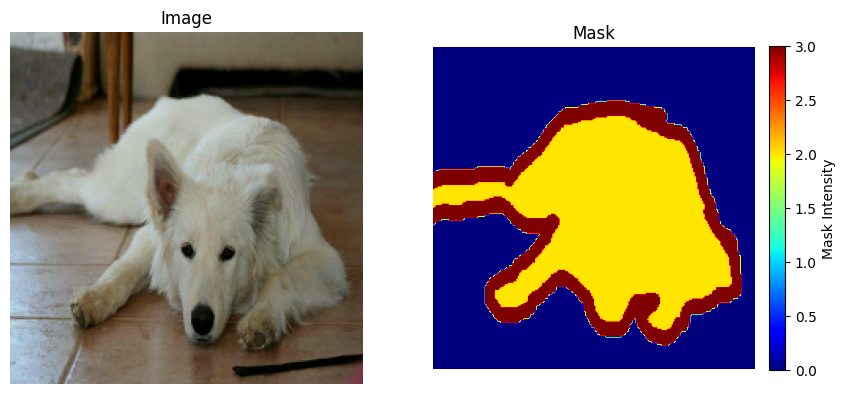

Image shape:  torch.Size([3, 224, 224])


In [5]:
N=random.randint(0,BATCH_SIZE-1)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N])
print("Image shape: ",images[N].shape)

# 2. Segmentation network design and implementation

### 2.a) UNet design and output verification

In [6]:
from model import UNet

model = UNet(input_channels=3, n_filters=64,  n_classes=4)
output = model(images)
print(output.shape)  


torch.Size([4, 4, 224, 224])


##### Output Dimention Verification

Mask shape:  torch.Size([4, 224, 224])


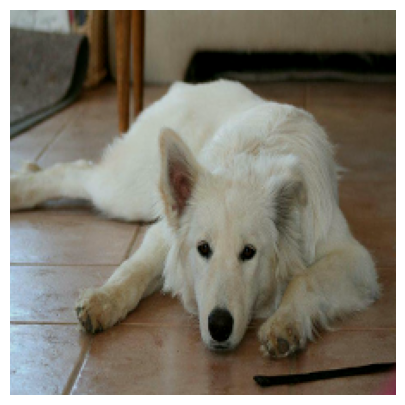

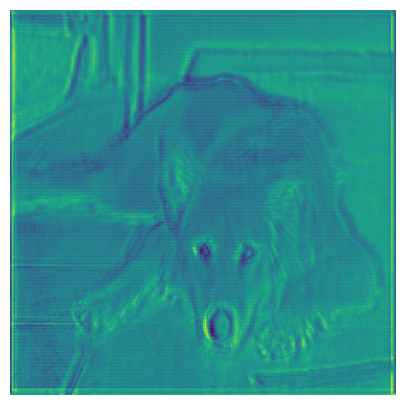

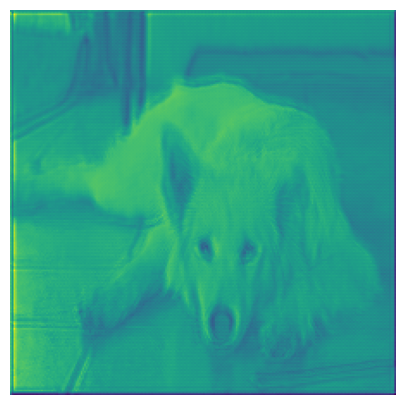

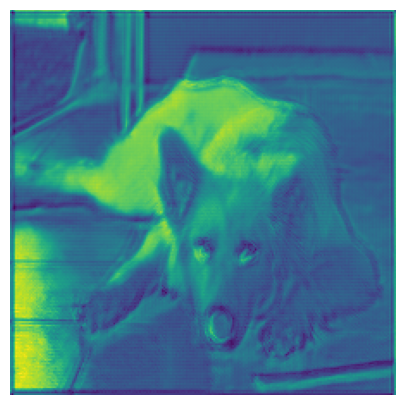

In [7]:
print("Mask shape: ",output[N].shape)
visualize(images[N].permute(1, 2, 0).detach().numpy())
visualize(output[N][0].detach().numpy())
visualize(output[N][1].detach().numpy())
visualize(output[N][2].detach().numpy())



##### The model architecture

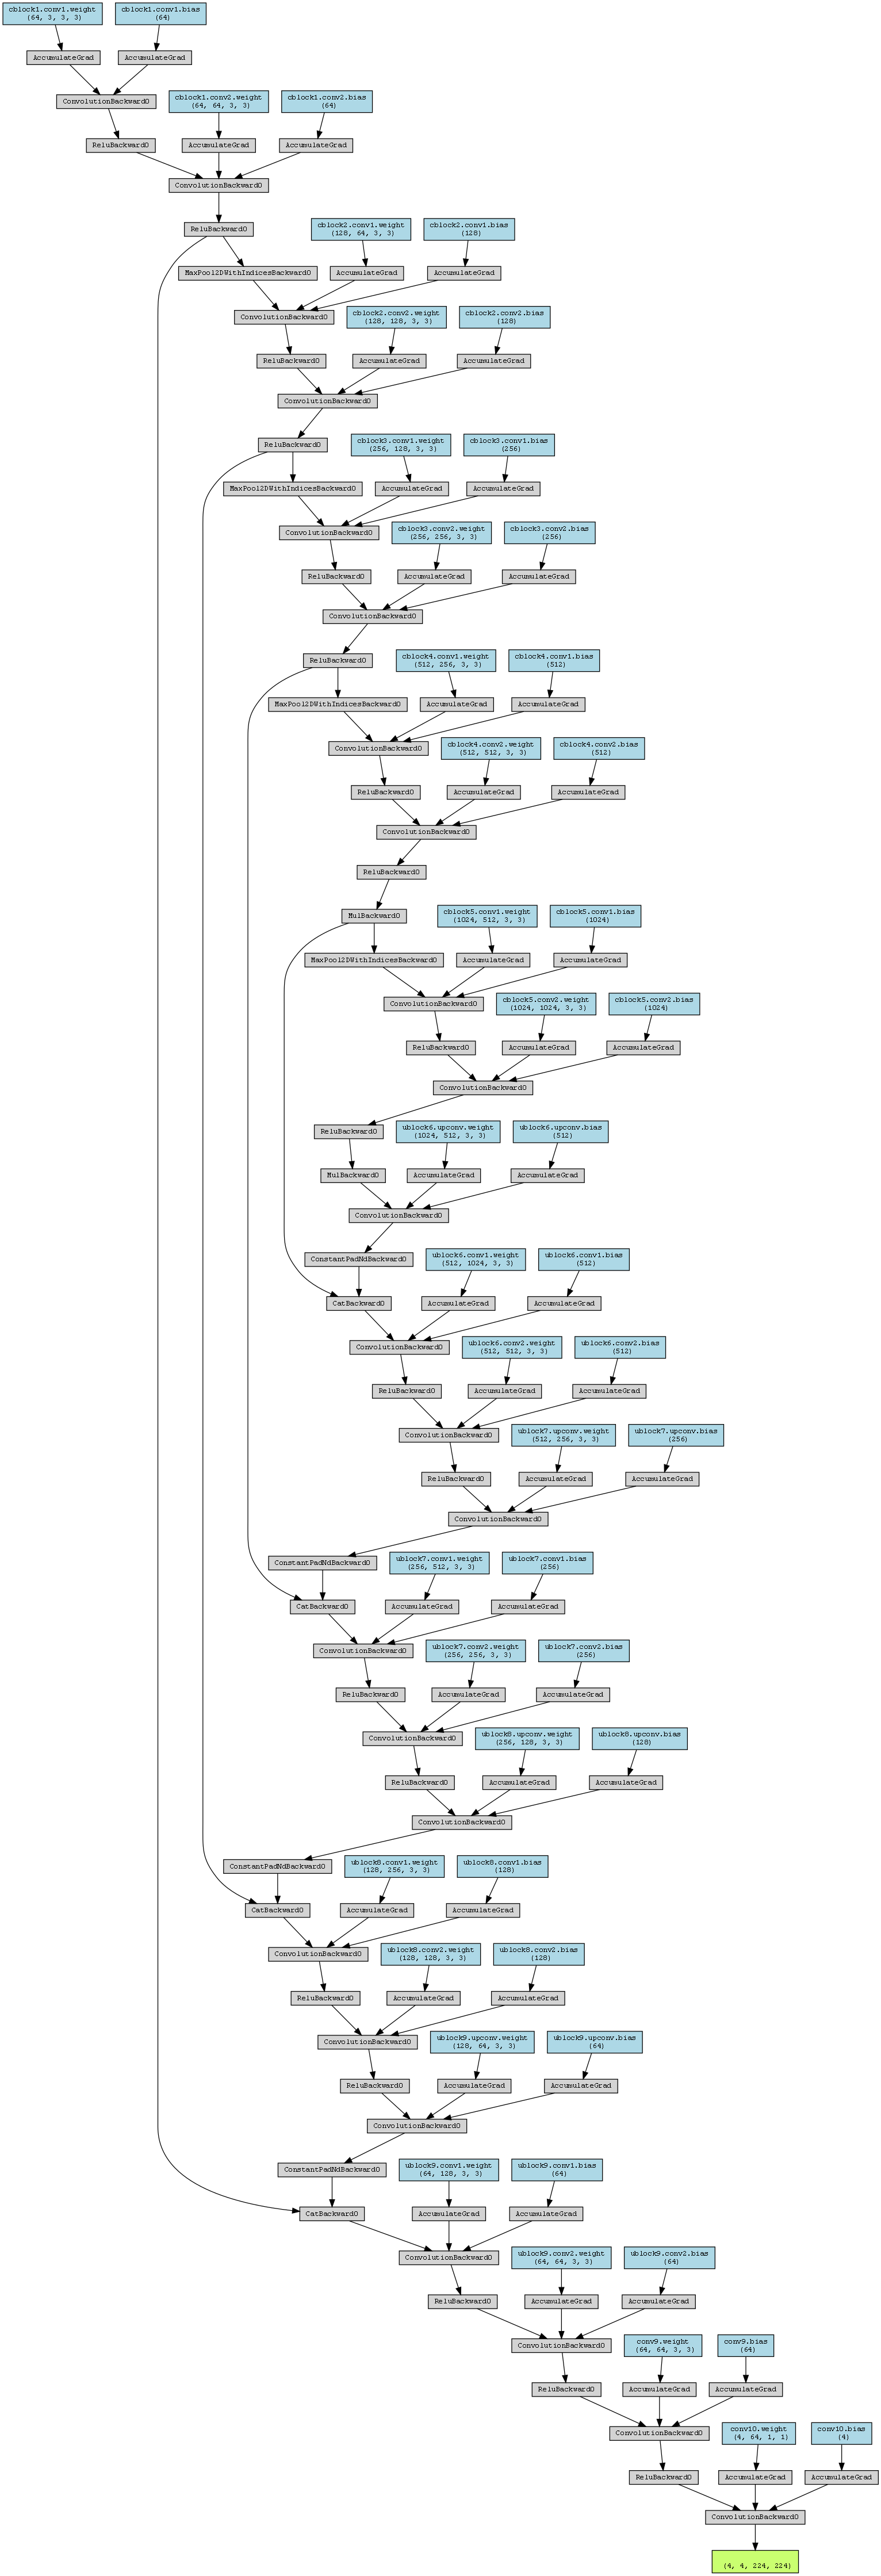

In [8]:
dot = torchviz.make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render("nn_graph")
from IPython.display import Image
Image("nn_graph.png")

### 2.b) Autoencoder pre-training

In [10]:
from model import Autoencoder
import torch.optim as optim
import torch.nn as nn

retrain = False

# Hyperparameters
epochs = 20
learning_rate = 0.0001


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder(input_channels=3, n_filters=64).to(device)
autoencoder.load_state_dict(torch.load("weights/autoencoder/autoencoder_weights_0.002858656363969203.pth", map_location=device))
optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

if retrain:
    min_loss = 1000
    # Training loop
    for epoch in range(epochs):
        autoencoder.train()
        total_loss = 0

        for images, _ in train_dataloader:  # Ignore masks
            images = images.to(device)

            # Forward pass
            outputs = autoencoder(images)
            loss = criterion(outputs, images)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        avg_loss = total_loss/len(train_dataloader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")
        if avg_loss < min_loss:
            min_loss = avg_loss
            torch.save(autoencoder.state_dict(), f"weights/autoencoder_weights_{min_loss}.pth")
            print("Model saved.")


##### Testing Autoencoder's Output

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


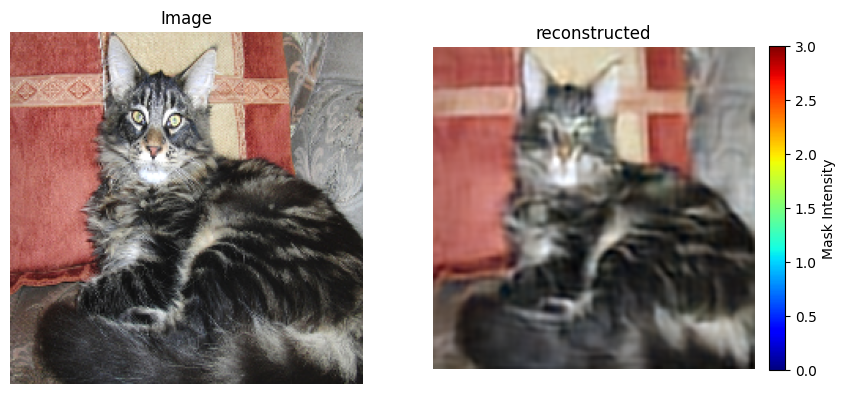

Image shape:  torch.Size([3, 224, 224])
Reconstructed shape:  torch.Size([3, 224, 224])


In [11]:
images, masks = next(iter(val_dataloader))
N=random.randint(0,BATCH_SIZE-1)

autoencoder.eval()
with torch.no_grad():
    reconstructed = autoencoder(images[N])


visualize(images[N].permute(1, 2, 0).numpy(),reconstructed.permute(1, 2, 0).numpy(),"reconstructed")
print("Image shape: ",images[N].shape)
print("Reconstructed shape: ",reconstructed.shape)

##### Leveraging Autoencoder's weights to train segmentation

In [12]:
from model import Autoencoder,UNet
import torch.optim as optim
import torch.nn as nn
autoencoder_weights = torch.load("weights/autoencoder/autoencoder_weights_0.002858656363969203.pth", map_location=device)


autoencoder = Autoencoder(input_channels=3, n_filters=64)
autoencoder.load_state_dict(autoencoder_weights, strict=False)

unet = UNet(input_channels=3, n_filters=64, n_classes=4)
# Copy encoder weights from Autoencoder to U-Net
unet.cblock1.load_state_dict(autoencoder.cblock1.state_dict())
unet.cblock2.load_state_dict(autoencoder.cblock2.state_dict())
unet.cblock3.load_state_dict(autoencoder.cblock3.state_dict())
unet.cblock4.load_state_dict(autoencoder.cblock4.state_dict())
unet.cblock5.load_state_dict(autoencoder.cblock5.state_dict())

print("Encoder weights successfully transferred from Autoencoder to U-Net!")

for param in [unet.cblock1.parameters(), unet.cblock2.parameters(),
              unet.cblock3.parameters(), unet.cblock4.parameters(),
              unet.cblock5.parameters()]:
    for p in param:
        p.requires_grad = False

print("Encoder frozen for fine-tuning U-Net!")

Encoder weights successfully transferred from Autoencoder to U-Net!
Encoder frozen for fine-tuning U-Net!


In [13]:
# Define training parameters
retrain = False
epochs = 10
learning_rate = 0.001
batch_size = 8  # Adjust based on your GPU memory
best_val_loss = float("inf")

# Move model to GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet.to(device)

# Define DataLoaders
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Define Loss and Optimizer
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, unet.parameters()), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

if retrain:
    print("Training U-Net for segmentation...")
    for epoch in range(epochs):
        # ---------------------------
        # Training Phase
        # ---------------------------
        unet.train()
        train_loss = 0
        for images, masks in train_dataloader:
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = unet(images)
            loss = criterion(outputs, masks)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)

        # ---------------------------
        # Validation Phase
        # ---------------------------
        unet.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_dataloader:
                images, masks = images.to(device), masks.to(device)

                outputs = unet(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)

        # Print loss for this epoch
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

        # Save the best model based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(unet.state_dict(), f"weights/autoencoder/autoencoder_unet/unet_best_{best_val_loss:.4f}.pth")
            print("Best model saved!")

print("Training complete!")


Training complete!


##### Testing Autoencoder-pretrained UNet's Output

In [14]:
unet = UNet(input_channels=3, n_filters=64).to(device)
unet.load_state_dict(torch.load("weights/autoencoder/autoencoder_unet/unet_best_1.1099.pth", map_location=device))

images, masks = next(iter(val_dataloader))
N=random.randint(0,BATCH_SIZE-1)

unet.eval()
with torch.no_grad():
    mask_pred = unet(images[N])


visualize(masks[N].permute(1, 2, 0).numpy(),reconstructed.permute(1, 2, 0).numpy(),"reconstructed")
print("Image shape: ",images[N].shape)
print("Reconstructed shape: ",reconstructed.shape)

c:\Users\jorge\anaconda3\envs\cv_segmentation\lib\site-packages\torch\nn\functional.py:1338: UserWarning:

dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.



IndexError: tuple index out of range